# 06 - Leave-One-Well-Out Comparison

Every result so far has been on a single blind well (SHANKLE). That's
useful for digging into confusion matrices and feature importance, but
one well is one split -- it doesn't tell you whether a model's edge is
real or just favorable luck on that particular well's facies mix.

This notebook runs full leave-one-well-out cross validation: each of
the 8 wells takes a turn as the blind test well, all 4 models get
refit on the remaining wells each time, so every model sees every
well as its blind test exactly once. That's 8 folds x 4 models = 32
fits, which is why it lives in `src/run_lowo.py` as a standalone
script (`python -m src.run_lowo`, ~1 minute) rather than being rerun
live in this notebook -- this notebook loads the saved results and
focuses on what they actually mean.

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("../results/leave_one_well_out.csv")
results.head(8)

,well,model,accuracy,adj_accuracy
0,CHURCHMAN BIBLE,LDA (classical),0.457921,0.819307
1,CHURCHMAN BIBLE,Random Forest,0.418317,0.801980
2,CHURCHMAN BIBLE,XGBoost,0.386139,0.787129
3,CHURCHMAN BIBLE,DepthWindowCNN,0.443069,0.806931
4,CROSS H CATTLE,LDA (classical),0.449102,0.898204
5,CROSS H CATTLE,Random Forest,0.417166,0.902196
6,CROSS H CATTLE,XGBoost,0.467066,0.870259
7,CROSS H CATTLE,DepthWindowCNN,0.564870,0.890220


In [2]:
summary = results.groupby("model")[["accuracy", "adj_accuracy"]].agg(["mean", "std"])
summary = summary.sort_values(("accuracy", "mean"), ascending=False)
summary.round(3)

accuracy        adj_accuracy       
                    mean    std         mean    std
model                                              
DepthWindowCNN     0.506  0.075        0.806  0.181
XGBoost            0.454  0.147        0.825  0.181
Random Forest      0.450  0.159        0.825  0.203
LDA (classical)    0.447  0.122        0.837  0.178

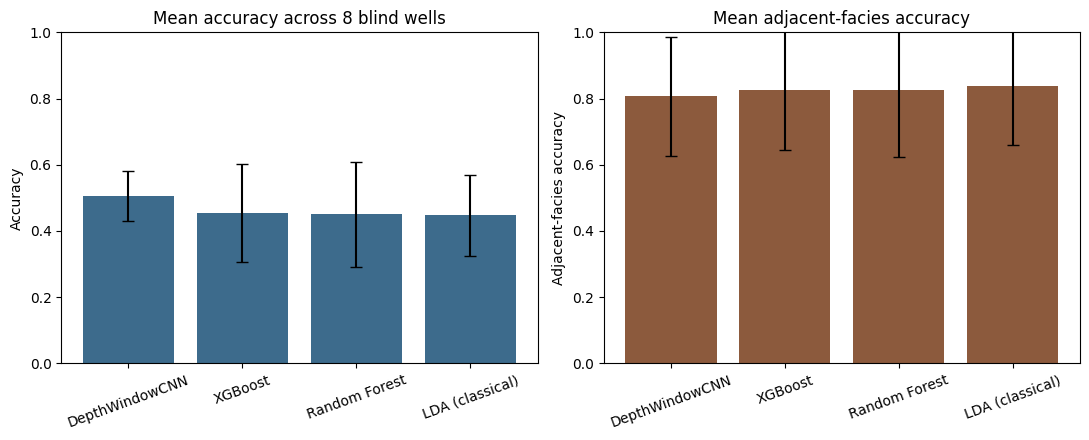

In [3]:
order = summary.index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

means = summary[("accuracy", "mean")]
stds = summary[("accuracy", "std")]
axes[0].bar(order, means, yerr=stds, capsize=4, color="#3d6b8c")
axes[0].set_ylabel("Accuracy"); axes[0].set_title("Mean accuracy across 8 blind wells")
axes[0].tick_params(axis="x", rotation=20)

means_adj = summary[("adj_accuracy", "mean")]
stds_adj = summary[("adj_accuracy", "std")]
axes[1].bar(order, means_adj, yerr=stds_adj, capsize=4, color="#8c5a3d")
axes[1].set_ylabel("Adjacent-facies accuracy"); axes[1].set_title("Mean adjacent-facies accuracy")
axes[1].tick_params(axis="x", rotation=20)
for ax in axes:
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("../figures/lowo_summary_bars.png", dpi=130)
plt.show()

The picture that a single blind well (`03`/`04`/`05`) suggested --
LDA edging out the tree models, CNN pulling ahead on raw accuracy --
partly holds and partly doesn't once averaged over all 8 wells:

- **DepthWindowCNN wins on mean accuracy** (0.506) but the standard
  deviation across wells (0.075) is the tightest of the four -- it's
  not just winning on average, it's more *consistent* well-to-well,
  which matters more than the mean alone for something meant to
  generalize to a well it's never seen.
- **LDA, RF, and XGBoost all cluster within about a point of each
  other** (0.447-0.454) on mean accuracy. The gap that looked real on
  SHANKLE alone (LDA 0.530 vs RF 0.465) mostly washes out once you
  average over all 8 wells -- SHANKLE happened to be a well where LDA
  did unusually well, not a systematic LDA-over-RF pattern. That's
  the entire reason this notebook exists rather than trusting the
  single-well numbers from `03`/`04`.
- **Adjacent-facies accuracy inverts the ranking**: LDA leads there
  (0.837), CNN trails (0.806). Confirms the trade-off noted at the end
  of `05` wasn't a SHANKLE-specific fluke either -- it holds up across
  wells.

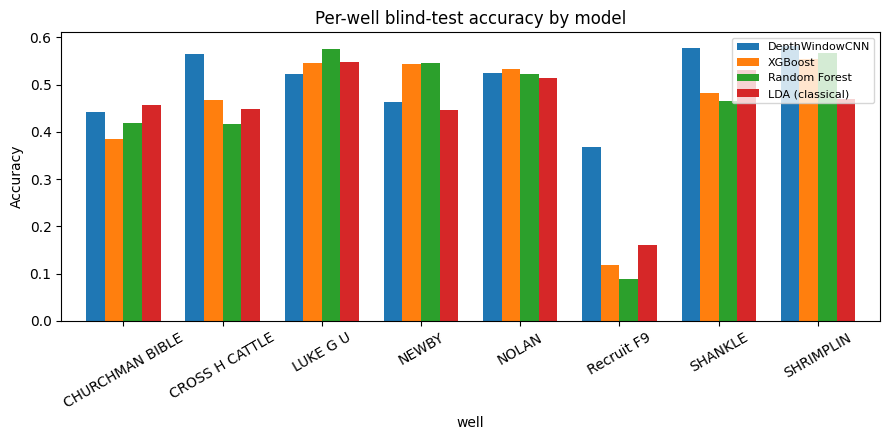

model,DepthWindowCNN,XGBoost,Random Forest,LDA (classical)
well,,,,
CHURCHMAN BIBLE,0.443,0.386,0.418,0.458
CROSS H CATTLE,0.565,0.467,0.417,0.449
LUKE G U,0.523,0.547,0.575,0.549
NEWBY,0.464,0.544,0.546,0.447
NOLAN,0.525,0.533,0.523,0.513
Recruit F9,0.368,0.118,0.088,0.162
SHANKLE,0.577,0.483,0.465,0.530
SHRIMPLIN,0.582,0.554,0.567,0.469


In [4]:
# per-well breakdown -- is the CNN's edge coming from a couple of
# wells, or is it broadly consistent?
pivot = results.pivot(index="well", columns="model", values="accuracy")
pivot = pivot[order]
fig, ax = plt.subplots(figsize=(9, 4.5))
pivot.plot(kind="bar", ax=ax, width=0.75)
ax.set_ylabel("Accuracy"); ax.set_title("Per-well blind-test accuracy by model")
ax.legend(fontsize=8, loc="upper right")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("../figures/lowo_per_well_accuracy.png", dpi=130)
plt.show()
pivot.round(3)

Recruit F9 is the hardest well for every single model, by a wide
margin -- and it's not close. That tracks with `01`: it's the 68-row
well, barely a tenth the size of the others, so there's very little
of it to learn from or generalize to. More interesting than the fact
that it's hard is *how much* each model struggles with it: the
tabular models collapse to 0.09-0.16 accuracy (worse than random
guessing off the class priors would even manage), while the CNN holds
up comparably better at 0.37. The likely explanation is that a
tabular row-by-row classifier gets nothing from a well this short --
there's no way for it to lean on cross-well pattern generalization
past whatever the per-well normalization already does -- while the
CNN's depth-window context still gives it *something* to work with
per sample even when the well itself is short. Worth flagging as a
hypothesis rather than a proven mechanism -- confirming it would mean
looking at Recruit F9's actual log tracks and facies sequence
directly, which is beyond scope here.

In [5]:
# does the same well rank as "hardest" for adjacent accuracy too, or
# does that metric tell a different story about difficulty?
pivot_adj = results.pivot(index="well", columns="model", values="adj_accuracy")[order]
pivot_adj.round(3)

model,DepthWindowCNN,XGBoost,Random Forest,LDA (classical)
well,,,,
CHURCHMAN BIBLE,0.807,0.787,0.802,0.819
CROSS H CATTLE,0.890,0.870,0.902,0.898
LUKE G U,0.870,0.918,0.937,0.950
NEWBY,0.857,0.879,0.870,0.849
NOLAN,0.839,0.863,0.863,0.877
Recruit F9,0.368,0.397,0.338,0.412
SHANKLE,0.904,0.958,0.951,0.951
SHRIMPLIN,0.915,0.932,0.934,0.938


## Bottom line

For a portfolio piece, the honest conclusion is more interesting than
a clean "ML wins" story: a from-scratch depth-window CNN picks up a
real, well-generalizing edge over both a classical statistical
baseline and two standard tabular ML models, but the edge is modest
(about 5 points of mean accuracy over the next best), it comes with a
real trade-off in adjacent-facies accuracy, and the plain tabular
models don't clearly separate from a 40-year-old classical method on
this dataset size. That's the actual result -- not "CNN > everything,"
but "sequence context is worth something here, and it's worth knowing
exactly what it costs."

See the project `README.md` for the full write-up and how to
reproduce this.